---

## Joseph — Data Analysis

### Deliverables
1. Geographic analysis with political data (re-run pipeline after Kevin fixes election file)
2. District concentration analysis
3. Iowa SF 496 case study
4. Time-series by state
5. Streisand Effect by state (now with 2,440 books)

### Source Files
- `outputs/state_geographic_analysis.csv` — 45 states with ban counts, per-capita, political lean
- `outputs/pen_categorized_full.csv` — 22,658 rows with state, district, school year
- `outputs/google_trends_cleaned.csv` — 2,440 rows with state and Streisand data

### Tutorial Videos
- Pandas groupby and aggregation: https://www.youtube.com/watch?v=txMdrV1Ut64
- Folium choropleth maps in Python: https://www.youtube.com/watch?v=4RnU5qKTfYY
- Plotly choropleth for US states: https://www.youtube.com/watch?v=aJmaw3QKMvk
- Time series analysis in Pandas: https://www.youtube.com/watch?v=r0Yrbbkopb4

### TASK 1: District Concentration Analysis

In [256]:
import pandas as pd

pen = pd.read_csv('outputs/pen_categorized_full.csv')

# District-level bans
district_bans = pen.groupby(['State', 'District']).agg(
    total_bans=('Title', 'size'),
    unique_titles=('Title', 'nunique'),
    school_years=('School Year', 'nunique'),
    # What categories are they banning?
    pct_lgbtq=('challenge_reasons', lambda x: x.str.contains('LGBTQ', na=False).mean() * 100),
    pct_sexual=('challenge_reasons', lambda x: x.str.contains('Sexual', na=False).mean() * 100),
    pct_race=('challenge_reasons', lambda x: x.str.contains('Race', na=False).mean() * 100),
).reset_index().sort_values('total_bans', ascending=False)

total = pen.shape[0]

# Concentration stats
print('DISTRICT CONCENTRATION')
for n in [5, 10, 20, 50]:
    top_n_bans = district_bans.head(n)['total_bans'].sum()
    pct = top_n_bans / total * 100
    print(f'  Top {n:2d} districts: {top_n_bans:,d} bans ({pct:.1f}% of all)')

print(f'  Total districts: {len(district_bans)}')

# Top 20 district profiles
print('\nTOP 20 DISTRICTS:')
for _, r in district_bans.head(20).iterrows():
    print(f"  {r['District'][:45]:45s} ({r['State']:12s}): {r['total_bans']:,d} bans, "
          f"{r['unique_titles']} titles, LGBTQ={r['pct_lgbtq']:.0f}%, Sexual={r['pct_sexual']:.0f}%, Race={r['pct_race']:.0f}%")

# Export
district_bans.to_csv('outputs/district_analysis.csv', index=False)

DISTRICT CONCENTRATION
  Top  5 districts: 5,818 bans (25.7% of all)
  Top 10 districts: 8,553 bans (37.7% of all)
  Top 20 districts: 11,915 bans (52.6% of all)
  Top 50 districts: 16,137 bans (71.2% of all)
  Total districts: 467

TOP 20 DISTRICTS:
  Escambia County Public Schools                (Florida     ): 1,827 bans, 1763 titles, LGBTQ=9%, Sexual=31%, Race=5%
  North East Independent School District        (Texas       ): 1,358 bans, 1334 titles, LGBTQ=27%, Sexual=27%, Race=5%
  Clay County School District                   (Florida     ): 1,259 bans, 1259 titles, LGBTQ=14%, Sexual=30%, Race=8%
  Orange County Public Schools                  (Florida     ): 765 bans, 736 titles, LGBTQ=7%, Sexual=35%, Race=6%
  Hillsborough County Public Schools            (Florida     ): 609 bans, 609 titles, LGBTQ=18%, Sexual=36%, Race=8%
  Department of Defense Educational Activity    (Nation      ): 590 bans, 590 titles, LGBTQ=60%, Sexual=18%, Race=14%
  Katy Independent School District     

In total, there are 467 school districts that have banned books in the US, totaling 22, 658 banned books. However, most districts ban relatively few books with 114 districts (24.41%) only having banned a single book. In fact, 251 districts (53.75%) banned 10 or less books, accounting for 780 books (3.44%). In contrast, The top 5 districts alone account for 5,818 books or 25.7% of all books banned. When we look at the top 50 districts, they account for 16,137 bans or 71.2% of all books. In other words, the majority of book bans stem from a small group of districts. At the state level, Florida, Iowa Texas, Tennessee and Pennsylvania make up the top 5 most banned states. However, Iowa alone has the most districts with bans at 124


In [241]:
ban_range = [1, 5, 10, 15, 20, 25]
print("BOOK BAN PROPORTION")
for book_count in ban_range:
  districts = district_bans[district_bans['total_bans'] <= book_count]
  district_ban_count = districts['total_bans'].sum()
  print(f"{book_count} or less books: {len(districts)} districts, {len(districts) / len(district_bans) * 100 :.2f}")
  print(f"({district_ban_count} books, {(district_ban_count/ total) * 100:.2f}%)")



BOOK BAN PROPORTION
1 or less books: 114 districts, 24.41
(114 books, 0.50%)
5 or less books: 202 districts, 43.25
(390 books, 1.72%)
10 or less books: 251 districts, 53.75
(780 books, 3.44%)
15 or less books: 282 districts, 60.39
(1178 books, 5.20%)
20 or less books: 302 districts, 64.67
(1551 books, 6.85%)
25 or less books: 327 districts, 70.02
(2121 books, 9.36%)


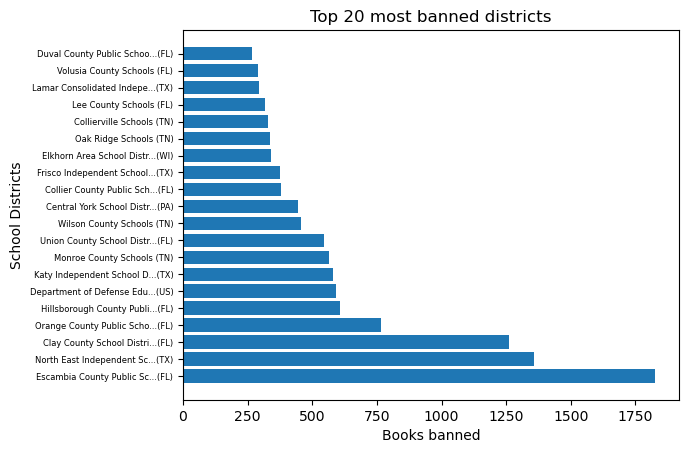

In [243]:
import matplotlib.pyplot as plt
top_20_districts = district_bans.sort_values(by='total_bans', ascending=False).iloc[:20].reset_index()
top_20_districts

truncated_district_names = top_20_districts[['District', 'State']]
truncated_district_names
truncated_district_names = truncated_district_names.apply(lambda x: f"{x['District'][:25]}...({state_abbrev[x['State']]})" 
                               if len(x['District']) > 25 else f"{x['District']} ({state_abbrev[x['State']]})", axis=1)
  

plt.barh(truncated_district_names, top_20_districts['total_bans'])
plt.title("Top 20 most banned districts")
plt.xlabel("Books banned")
plt.ylabel("School Districts")
plt.yticks(fontsize=6)
plt.show()

In [167]:
state_totals.sort_values(by='total_bans', ascending=False).head()

,State,total_bans,state_abbrev
5,Florida,8837,FL
10,Iowa,3798,IA
37,Texas,3744,TX
36,Tennessee,2016,TN
32,Pennsylvania,737,PA


In [244]:
district_bans.groupby('State').size().sort_values(ascending=False).head()

State
Iowa            124
Florida          58
Texas            36
Pennsylvania     23
Missouri         18
dtype: int64

In [255]:
iowa_bans = district_bans[district_bans['State'] == 'Iowa']
iowa_bans.sort_values(by='total_bans', ascending=False)

,State,District,total_bans,unique_titles,school_years,pct_lgbtq,pct_sexual,pct_race
161,Iowa,Nevada Community School District,242,242,1,10.330579,44.214876,5.785124
114,Iowa,Clear Creek-Amana Community School District,226,226,1,49.115044,26.991150,4.424779
211,Iowa,West Burlington Independent School District,141,141,1,4.255319,53.900709,4.964539
115,Iowa,Clear Lake Community School District,131,131,1,9.160305,44.274809,2.290076
216,Iowa,Winterset Community School District,90,90,1,23.333333,42.222222,8.888889
...,...,...,...,...,...,...,...,...
159,Iowa,Murray Community School District,1,1,1,0.000000,0.000000,0.000000
130,Iowa,Grinnell-Newburg Community School District,1,1,1,0.000000,0.000000,0.000000
131,Iowa,Griswold Community Schools,1,1,1,0.000000,0.000000,0.000000
138,Iowa,Iowa City Community Schools,1,1,1,100.000000,100.000000,0.000000


In [242]:
import pandas as pd
import plotly.express as px

# Use your district-level data aggregated by state
pen = pd.read_csv('outputs/pen_categorized_full.csv')
state_totals = pen.groupby('State').agg(total_bans=('Title', 'size')).reset_index()

# map full names to abbreviations if needed
state_abbrev = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT',
    'Delaware': 'DE', 'District of Columbia': 'DC', 'Florida': 'FL',
    'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL',
    'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS', 'Kentucky': 'KY',
    'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD', 'Massachusetts': 'MA',
    'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS', 'Missouri': 'MO',
    'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH',
    'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC',
    'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR',
    'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT',
    'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV',
    'Wisconsin': 'WI', 'Wyoming': 'WY', 'Nation': 'US',  # if you have a "Nation" row
}
state_totals['state_abbrev'] = state_totals['State'].map(state_abbrev)

# US state choropleth 
fig = px.choropleth(
    state_totals,
    locations='state_abbrev',
    locationmode='USA-states',
    color='total_bans',
    scope='usa',
    color_continuous_scale='Reds',
    title='Book bans by state'
)
fig.show()

### TASK 2: Iowa SF 496 Case Study

In [93]:
import pandas as pd
import numpy as np

pen = pd.read_csv('outputs/pen_categorized_full.csv')

iowa = pen[pen['State'] == 'Iowa'].copy()

print(f'Iowa total bans: {len(iowa)}')
print(f'\nBy school year:')
print(iowa.groupby('School Year').size().to_string())

print(f'\nBy ban status:')
print(iowa['Ban Status'].value_counts().to_string())

# Challenge reason profile for Iowa vs national
print('\nIowa challenge reasons vs national:')
for reason in ['LGBTQ', 'Race', 'Sexual', 'Violence', 'Mental', 'Age']:
    iowa_pct = iowa['challenge_reasons'].str.contains(reason, na=False).mean() * 100
    national_pct = pen['challenge_reasons'].str.contains(reason, na=False).mean() * 100
    diff = iowa_pct - national_pct
    print(f'  {reason:12s}: Iowa={iowa_pct:5.1f}%, National={national_pct:5.1f}%, diff={diff:+.1f}%')

# Iowa 2023-24 specifically (the SF 496 year)
iowa_2324 = iowa[iowa['School Year'] == '2023-24']
print(f'\nIowa 2023-24:')
print(f'  Bans: {len(iowa_2324)}')
print(f'  Districts: {iowa_2324["District"].nunique()}')
print(f'  Unique titles: {iowa_2324["Title"].nunique()}')

# Top Iowa districts
print('\nTop 10 Iowa districts:')
iowa_districts = iowa.groupby('District').size().nlargest(10)
for d, n in iowa_districts.items():
    print(f'  {d}: {n}')

Iowa total bans: 3798

By school year:
School Year
2021-22       8
2022-23       6
2023-24    3671
2024-25     113

By ban status:
Ban Status
Banned                                  2295
Banned Pending Investigation            1477
Banned by Restriction                     19
Banned from Libraries and Classrooms       3
Banned from Libraries                      3
Banned from Classrooms                     1

Iowa challenge reasons vs national:
  LGBTQ       : Iowa= 16.0%, National= 20.3%, diff=-4.3%
  Race        : Iowa=  9.0%, National=  8.9%, diff=+0.0%
  Sexual      : Iowa= 42.8%, National= 34.6%, diff=+8.2%
  Violence    : Iowa= 29.9%, National= 26.2%, diff=+3.8%
  Mental      : Iowa= 25.5%, National= 17.1%, diff=+8.5%
  Age         : Iowa= 65.9%, National= 64.5%, diff=+1.5%

Iowa 2023-24:
  Bans: 3671
  Districts: 117
  Unique titles: 1142

Top 10 Iowa districts:
  Nevada Community School District: 242
  Clear Creek-Amana Community School District: 226
  West Burlington Independe

Iowa SF 496 is a 2023 Iowa law that prohibits schools from providing books that include themes of sex acts, gender identity and sexual orientation to students from kindergarten through grade six. Any books containing such content had to be removed. From the period of 2023-2024, a total of 3,671 books were banned. This was an extreme increase from 8 from 2021-2022 and 6 from 2022-2023. For 2024-2025, Iowa saw 113 books get added to the ban. Of the books affected, 1477 books are pending investigation, which leaves 2295 books banned in some way. Out of the selected ban reasons of the content being LGBTQ, Race, Sexual, Violence, Mental and Age, all saw rates higher than the national average except for LGBTQ, which was 4.28% lower. Sexual and Mental reasons had the highest percentage difference than the national average at 8.20% and 8.45% respectively. 

https://en.wikipedia.org/wiki/Iowa_Senate_File_496

https://pen.org/press-release/iowa-law-that-led-to-thousands-of-book-bans-in-school-libraries-will-go-back-into-force-as-judge-lifts-injunction/

https://www.legis.iowa.gov/docs/publications/LGE/90/SF496.pdf


Iowa Sf 496 was a 

In [114]:
def apply_labels(x, y, label, font):
  for i in range(len(x)):
    plt.text(x[i], y[i]* 1.0, label[i], ha='center', fontsize=font)

In [115]:
iowa['challenge_reasons']

challenge_reason_df = pd.DataFrame({
    'Reason': pd.Series(dtype='str'),
    'Iowa': pd.Series(dtype='float'),
    'National': pd.Series(dtype='float'),
    'Diff': pd.Series(dtype='float')
})
challenge_reason_df

for reason in ['LGBTQ', 'Race', 'Sexual', 'Violence', 'Mental', 'Age']:
    iowa_pct = iowa['challenge_reasons'].str.contains(reason, na=False).mean() * 100
    national_pct = pen['challenge_reasons'].str.contains(reason, na=False).mean() * 100
    diff = iowa_pct - national_pct
    new_row = pd.DataFrame([{'Reason': reason, 'Iowa': iowa_pct, 'National': national_pct, 'Diff': diff}])
    challenge_reason_df = pd.concat([challenge_reason_df, new_row], ignore_index=True)
challenge_reason_df

,Reason,Iowa,National,Diff
0,LGBTQ,15.982096,20.257746,-4.275650
1,Race,8.978410,8.941654,0.036756
2,Sexual,42.785677,34.583811,8.201865
3,Violence,29.936809,26.185012,3.751797
4,Mental,25.539758,17.088887,8.450871
5,Age,65.929437,64.462883,1.466554


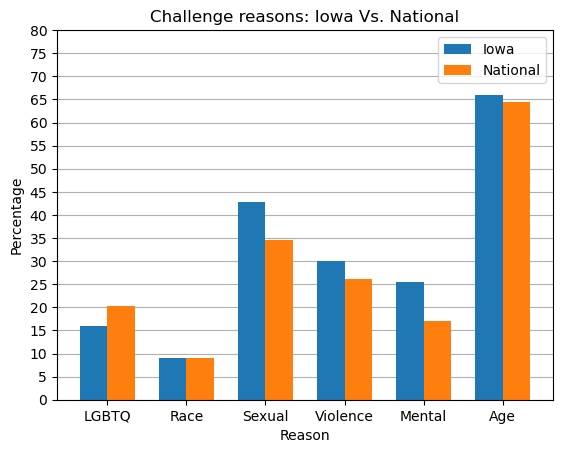

In [152]:
x = np.arange(len(challenge_reason_df))

width = 0.35
plt.bar(x - width/2, challenge_reason_df['Iowa'], width, label='Iowa', zorder=2)
plt.bar(x + width/2, challenge_reason_df['National'], width, label='National', zorder=2)

plt.yticks(np.arange(0, 85, 5))
plt.xticks(x, challenge_reason_df['Reason'])

plt.legend()
plt.grid(axis='y')

plt.title('Challenge reasons: Iowa Vs. National')
plt.ylabel('Percentage')
plt.xlabel('Reason')
plt.show()

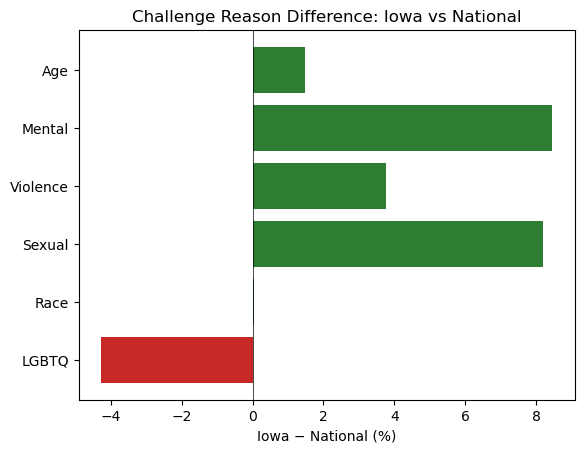

In [ ]:
x = np.arange(len(challenge_reason_df))
colors = ['#2e7d32' if d >= 0 else '#c62828' for d in challenge_reason_df['Diff']]  # green positive, red negative
plt.barh(challenge_reason_df['Reason'], challenge_reason_df['Diff'].tolist(), color=colors)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('Iowa − National (%)')
plt.title('Challenge Reason Difference: Iowa vs National')
plt.show()


### TASK 3: Time-Series by State

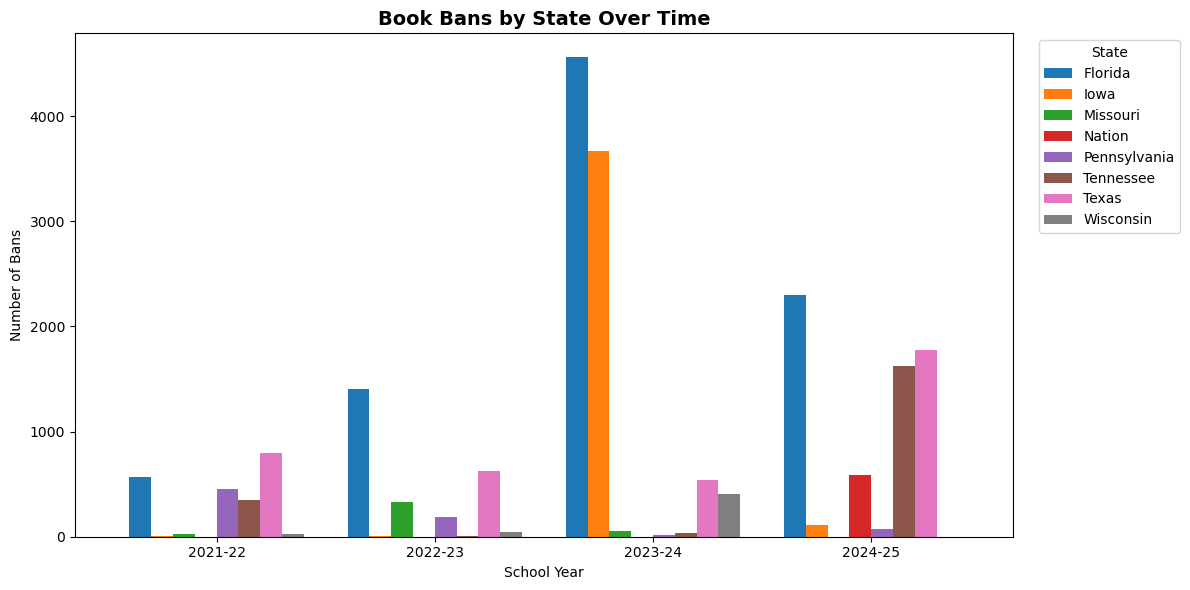


State acceleration (2023-24 → 2024-25):
  Florida             :  4561 →  2304 (-49%)
  Iowa                :  3671 →   113 (-97%)
  Texas               :   538 →  1781 (+231%)
  Tennessee           :    34 →  1622 (+4671%)
  Pennsylvania        :    20 →    73 (+265%)
  Wisconsin           :   408 →     2 (-100%)
  Missouri            :    57 →     2 (-96%)


In [260]:
import pandas as pd
import matplotlib.pyplot as plt

pen = pd.read_csv('outputs/pen_categorized_full.csv')

# Bans by state and school year
state_year = pen.groupby(['State', 'School Year']).size().reset_index(name='bans')

# Pivot for top 8 states
top_states = pen.groupby('State').size().nlargest(8).index.tolist()
pivot = state_year[state_year['State'].isin(top_states)].pivot_table(
    index='School Year', columns='State', values='bans', fill_value=0)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind='bar', ax=ax, width=0.8)
ax.set_ylabel('Number of Bans')
ax.set_title('Book Bans by State Over Time', fontsize=14, fontweight='bold')
ax.legend(title='State', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('viz_state_time_series.png', dpi=200, bbox_inches='tight')
plt.show()

# Acceleration: which states are growing vs shrinking?
print('\nState acceleration (2023-24 → 2024-25):')
for state in top_states:
    s = state_year[state_year['State'] == state].set_index('School Year')['bans']
    if '2023-24' in s.index and '2024-25' in s.index:
        change = (s['2024-25'] - s['2023-24']) / s['2023-24'] * 100
        print(f'  {state:20s}: {s.get("2023-24", 0):5d} → {s.get("2024-25", 0):5d} ({change:+.0f}%)')

The peak in book bans from 2023-24 and 2024-25 are explained by the Iowa SF 496 law, but the state did see a 97% drop in the number of books banned. Among the other leading states in bans, Florida stands with out a consistently increasing number of books banned per year before peaking in 2023-2024. However, while Florida had a 49% drop in books banned, the state still banned the most book at a count of 2,304. Texas also had a constant number of book bans accross the years, but it saw a 231% increase up from 584 to 1781 books. Out of all states, Tennessee saw the most shocking jump from 34 to 1622 books banned in the span of a year--a 4671% increase--. 

### TASK 4: Streisand Effect by State

In [261]:

import pandas as pd
from scipy import stats

gt = pd.read_csv('outputs/google_trends_cleaned.csv')
state_geo = pd.read_csv('outputs/state_geographic_analysis.csv')

# Check if state column has data
print(f'States in GT data: {gt["state"].nunique()}')
print(f'State value counts:')
print(gt['state'].value_counts().head(15))

# State-level Streisand stats (only states with >= 10 books)
gt_state = gt.groupby('state').agg(
    n_books=('book_title', 'size'),
    mean_spike=('spike_magnitude', 'mean'),
    spike_rate=('searches_increased', 'mean'),
    mean_pct=('percent_change', lambda x: x.replace([float('inf'), float('-inf')], float('nan')).mean())
).reset_index()

gt_state = gt_state[gt_state['n_books'] >= 10].sort_values('mean_spike', ascending=False)
print('\nStreisand Effect by state (≥10 books):')
for _, r in gt_state.iterrows():
    print(f"  {r['state']:20s}: N={r['n_books']:4.0f}, spike rate={r['spike_rate']*100:5.1f}%, mean Δ={r['mean_spike']:+5.2f}")

# Merge with political data for correlation
merged = gt_state.rename(columns={'state': 'state_name'}).merge(
    state_geo[['state_name', 'trump_pct', 'political_lean']], on='state_name', how='left')

valid = merged.dropna(subset=['trump_pct'])
if len(valid) >= 5:
    r, p = stats.spearmanr(valid['trump_pct'], valid['spike_rate'])
    print(f'\nTrump % vs spike rate: ρ={r:.4f}, p={p:.4f} (N={len(valid)})')

# Export
gt_state.to_csv('outputs/streisand_by_state.csv', index=False)

States in GT data: 24
State value counts:
state
Florida         1272
Texas            504
Tennessee        305
Iowa             140
Missouri          66
Wisconsin         38
Pennsylvania      34
Virginia          15
Maine             11
Kentucky          11
Oklahoma           9
Georgia            6
Utah               5
Idaho              4
Michigan           4
Name: count, dtype: int64

Streisand Effect by state (≥10 books):
  Tennessee           : N= 305, spike rate= 51.1%, mean Δ=+1.34
  Missouri            : N=  66, spike rate= 37.9%, mean Δ=+1.22
  Texas               : N= 504, spike rate= 47.4%, mean Δ=+0.28
  Florida             : N=1272, spike rate= 49.6%, mean Δ=+0.05
  Iowa                : N= 140, spike rate= 45.7%, mean Δ=+0.02
  Kentucky            : N=  11, spike rate= 36.4%, mean Δ=-0.01
  Wisconsin           : N=  38, spike rate= 39.5%, mean Δ=-0.64
  Virginia            : N=  15, spike rate= 40.0%, mean Δ=-0.81
  Pennsylvania        : N=  34, spike rate= 55.9%, mean Δ=-

KeyError: "['trump_pct', 'political_lean'] not in index"